# Bodrum Hotel & Destination Intelligence
## 10 - Milas-Bodrum Airport × Tourism Joint Analysis

Bu notebook Milas–Bodrum Havalimanı 2025 aylık yolcu trafiği ile Muğla ili 2025 aylık konaklama
tesisi gelişlerinin ortak sezonluk hareketini inceler.

> **Airport passenger ≠ tourist arrival.** Havalimanı yolcusu yerel halk, iş/ziyaret amaçlı yolcu
> veya başka destinasyona devam eden kişileri içerebilir. Muğla accommodation arrival ise
> konaklama tesisine geliş kaydıdır ve benzersiz kişi olmak zorunda değildir.

Analiz co-movement, seasonal alignment ve proxy relationship çerçevesindedir. Regression,
forecasting, Granger/causal analysis, destination-level monthly join veya ekonomik etki tahmini
yapılmaz. Muğla aylık verisi Bodrum aylık turizmi olarak adlandırılmaz.


### 1. Kurulum ve gerçek dosya yolları

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from bodrum_intelligence.airport_tourism import (
    airport_quality_audit,
    airport_seasonality_metrics,
    build_joint_monthly,
    correlation_pair,
    cross_domain_correlations,
    lag_correlations,
    peak_alignment,
    period_coverage,
    season_summary,
)

AIRPORT_PATH = PROJECT_ROOT / "data" / "external" / "airport" / "milas_bodrum_airport_monthly_2025.csv"
TOURISM_PATH = PROJECT_ROOT / "data" / "processed" / "tourism_demand_monthly_features_2025.csv"
SEASON_SUMMARY_PATH = PROJECT_ROOT / "reports" / "tourism_season_group_summary.csv"
TOURISM_CORR_PATH = PROJECT_ROOT / "reports" / "tourism_monthly_correlations_2025.csv"
TOURISM_FINDINGS_PATH = PROJECT_ROOT / "reports" / "tourism_demand_key_findings.txt"
BODRUM_PROFILE_PATH = PROJECT_ROOT / "reports" / "bodrum_tourism_profile_2025.csv"
DESTINATION_CONTEXT_PATH = PROJECT_ROOT / "data" / "processed" / "destination_intelligence_enriched.csv"
PROCESSED_OUTPUT = PROJECT_ROOT / "data" / "processed" / "airport_tourism_monthly_2025.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures" / "airport_tourism"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

required_paths = [AIRPORT_PATH, TOURISM_PATH, SEASON_SUMMARY_PATH, TOURISM_CORR_PATH, TOURISM_FINDINGS_PATH]
optional_paths = [path for path in [BODRUM_PROFILE_PATH, DESTINATION_CONTEXT_PATH] if path.exists()]
assert all(path.exists() for path in required_paths)
input_paths = required_paths + optional_paths
input_hashes_before = {path: hashlib.sha256(path.read_bytes()).hexdigest() for path in input_paths}

airport_raw = pd.read_csv(AIRPORT_PATH)
tourism_raw = pd.read_csv(TOURISM_PATH)
bodrum_profile = pd.read_csv(BODRUM_PROFILE_PATH) if BODRUM_PROFILE_PATH.exists() else None
destination_context = pd.read_csv(DESTINATION_CONTEXT_PATH) if DESTINATION_CONTEXT_PATH.exists() else None

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 90)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
print("Airport:", airport_raw.shape)
print("Muğla monthly tourism:", tourism_raw.shape)


Airport: (12, 16)
Muğla monthly tourism: (12, 30)


In [2]:
PRIMARY = "#2F6B7C"
SECONDARY = "#4C956C"
ACCENT = "#C1666B"
HIGHLIGHT = "#D9A404"
PURPLE = "#7A5C8E"
NEUTRAL = "#777777"


def save_fig(fig, filename):
    fig.tight_layout()
    path = FIGURES_DIR / filename
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return path


def monthly_lines(frame, columns, labels, colors, title, ylabel, filename, mean_line=False):
    fig, ax = plt.subplots(figsize=(11, 5.8))
    months = frame["month_name_tr"]
    for column, label, color in zip(columns, labels, colors):
        ax.plot(months, frame[column], marker="o", linewidth=2.2, color=color, label=label)
    if mean_line:
        ax.axhline(100, color=NEUTRAL, linestyle="--", linewidth=1, label="2025 aylık ortalama=100")
    ax.set(title=title, xlabel="Ay", ylabel=ylabel)
    ax.tick_params(axis="x", rotation=40); ax.grid(alpha=0.22); ax.legend()
    save_fig(fig, filename)


def labeled_scatter(frame, x, y, title, xlabel, ylabel, filename):
    stats_row = correlation_pair(frame, x, y)
    fig, ax = plt.subplots(figsize=(8.8, 5.8))
    ax.scatter(frame[x], frame[y], s=68, color=PRIMARY, alpha=0.85)
    for row in frame.itertuples():
        ax.annotate(str(row.month_name_tr)[:3], (getattr(row, x), getattr(row, y)),
                    xytext=(5, 5), textcoords="offset points", fontsize=8)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel); ax.grid(alpha=0.22)
    ax.text(0.03, 0.96,
            f"Pearson r={stats_row['pearson_r']:.3f}\nSpearman ρ={stats_row['spearman_rho']:.3f}\nn={stats_row['n']}",
            transform=ax.transAxes, va="top", bbox=dict(boxstyle="round", facecolor="white", edgecolor=NEUTRAL))
    save_fig(fig, filename)
    return stats_row


### 2. Grain / source audit

In [3]:
input_summary = pd.DataFrame([
    {
        "dataset_name": "Milas-Bodrum Airport Monthly 2025", "row_count": len(airport_raw),
        "geography": airport_raw["airport"].iloc[0], "geography_level": "airport / regional gateway",
        "time_grain": "monthly", "start_period": airport_raw["period"].min(), "end_period": airport_raw["period"].max(),
        "main_metrics": "domestic, international, total passengers; cumulative passengers",
        "source_origin": "DHMİ passenger statistics (documented in data_status/source_url)",
    },
    {
        "dataset_name": "Muğla Tourism Monthly 2025", "row_count": len(tourism_raw),
        "geography": tourism_raw["geography"].iloc[0], "geography_level": tourism_raw["geography_level"].iloc[0],
        "time_grain": "monthly", "start_period": tourism_raw["period"].min(), "end_period": tourism_raw["period"].max(),
        "main_metrics": "domestic/foreign/total accommodation arrivals, overnights, occupancy",
        "source_origin": tourism_raw["source_origin"].iloc[0],
    },
], columns=["dataset_name", "row_count", "geography", "geography_level", "time_grain", "start_period", "end_period", "main_metrics", "source_origin"])
display(input_summary)
display(Markdown(
    "**Kapsam ayrımı:** Havalimanı bölgesel bir gateway; turizm serisi Muğla ilindeki konaklama "
    "tesislerine gelişlerdir. Aynı ayı paylaşmaları aynı population/grain oldukları anlamına gelmez."
))


,dataset_name,row_count,geography,geography_level,time_grain,start_period,end_period,main_metrics,source_origin
0,Milas-Bodrum Airport Monthly 2025,12,Muğla Milas-Bodrum,airport / regional gateway,monthly,2025-01,2025-12,"domestic, international, total passengers; cumulative passengers",DHMİ passenger statistics (documented in data_status/source_url)
1,Muğla Tourism Monthly 2025,12,Muğla,province,monthly,2025-01,2025-12,"domestic/foreign/total accommodation arrivals, overnights, occupancy",T.C. Kültür ve Turizm Bakanlığı konaklama istatistikleri


**Kapsam ayrımı:** Havalimanı bölgesel bir gateway; turizm serisi Muğla ilindeki konaklama tesislerine gelişlerdir. Aynı ayı paylaşmaları aynı population/grain oldukları anlamına gelmez.

### 3. Airport data audit ve kümülatif fark kontrolü

In [4]:
airport_checks, airport_audited = airport_quality_audit(airport_raw)
display(airport_checks)
display(airport_audited[[
    "period", "monthly_total_passengers", "cumulative_total_passengers",
    "derived_total_from_cumulative", "cumulative_total_monthly_difference",
    "passenger_total_difference", "international_share_difference_pp",
]])
assert not airport_checks["status"].eq("FAIL").any()


,check,value,status
0,row_count,12,PASS
1,unique_period,12,PASS
2,missing_cells,0,PASS
3,negative_passenger_values,0,PASS
4,monthly_passenger_total_mismatch_rows,0,PASS
5,cumulative_domestic_mismatch_rows,0,PASS
6,cumulative_international_mismatch_rows,0,PASS
7,cumulative_total_mismatch_rows,0,PASS
8,annual_sum_minus_year_end_cumulative,0,PASS


,period,monthly_total_passengers,cumulative_total_passengers,derived_total_from_cumulative,cumulative_total_monthly_difference,passenger_total_difference,international_share_difference_pp
0,2025-01,103233,103233,"103,233.0000",0.0000,0,-0.0032
1,2025-02,85336,188569,"85,336.0000",0.0000,0,-0.0030
2,2025-03,109367,297936,"109,367.0000",0.0000,0,0.0011
3,2025-04,213933,511869,"213,933.0000",0.0000,0,-0.0034
4,2025-05,406151,918020,"406,151.0000",0.0000,0,-0.0012
5,2025-06,611992,1530012,"611,992.0000",0.0000,0,-0.0004
6,2025-07,769252,2299264,"769,252.0000",0.0000,0,-0.0011
7,2025-08,822443,3121707,"822,443.0000",0.0000,0,-0.0042
8,2025-09,640401,3762108,"640,401.0000",0.0000,0,0.0002
9,2025-10,415256,4177364,"415,256.0000",0.0000,0,-0.0025


In [5]:
airport_annual_sum = int(airport_audited["monthly_total_passengers"].sum())
airport_year_end_cumulative = int(airport_audited.iloc[-1]["cumulative_total_passengers"])
display(Markdown(
    f"**Audit sonucu:** 12 aylık airport total passengers toplamı {airport_annual_sum:,}; Aralık "
    f"kümülatif toplamı {airport_year_end_cumulative:,}; fark {airport_annual_sum - airport_year_end_cumulative:,}. "
    f"Aylık passenger değerlerinin kümülatif farklardan türetilmiş olduğu metadata ile birlikte korunur."
))


**Audit sonucu:** 12 aylık airport total passengers toplamı 4,412,884; Aralık kümülatif toplamı 4,412,884; fark 0. Aylık passenger değerlerinin kümülatif farklardan türetilmiş olduğu metadata ile birlikte korunur.

### 4. Tourism data audit ve period coverage

In [6]:
tourism_checks = pd.DataFrame([
    ("row_count", len(tourism_raw), "PASS" if len(tourism_raw) == 12 else "FAIL"),
    ("unique_period", tourism_raw["period"].nunique(), "PASS" if tourism_raw["period"].is_unique else "FAIL"),
    ("missing_core_cells", int(tourism_raw[["total_arrivals", "foreign_arrivals", "domestic_arrivals", "total_overnights", "occupancy_rate_pct"]].isna().sum().sum()), "PASS"),
    ("arrival_total_mismatch_rows", int((tourism_raw["domestic_arrivals"] + tourism_raw["foreign_arrivals"] - tourism_raw["total_arrivals"]).ne(0).sum()), "PASS"),
    ("occupancy_out_of_range_rows", int((~tourism_raw["occupancy_rate_pct"].between(0, 100)).sum()), "PASS"),
], columns=["check", "value", "status"])
display(tourism_checks)
coverage = period_coverage(airport_raw, tourism_raw)
display(coverage)


,check,value,status
0,row_count,12,PASS
1,unique_period,12,PASS
2,missing_core_cells,0,PASS
3,arrival_total_mismatch_rows,0,PASS
4,occupancy_out_of_range_rows,0,PASS


,metric,value
0,airport_period_n,12
1,tourism_period_n,12
2,matched_period_n,12
3,airport_only_periods,
4,tourism_only_periods,


### 5. 12 aylık ortak tablo

In [7]:
joint = build_joint_monthly(airport_raw, tourism_raw)
assert len(joint) == 12 and joint["period"].is_unique
assert joint["period"].tolist() == [f"2025-{month:02d}" for month in range(1, 13)]
display(joint)


,period,year,month_name_tr,airport_domestic_passengers,airport_international_passengers,airport_total_passengers,tourism_domestic_arrivals,tourism_foreign_arrivals,tourism_total_arrivals,tourism_total_overnights,tourism_occupancy_rate_pct,tourism_avg_stay_nights,tourism_foreign_share_pct,season_group,airport_monthly_share_pct,airport_international_share_pct,airport_domestic_share_pct,airport_total_index,airport_domestic_index,airport_international_index,tourism_total_arrivals_index,tourism_domestic_index,tourism_foreign_index,tourism_overnights_index,tourism_occupancy_index,share_gap_pp,tourism_arrivals_per_airport_passenger_proxy_ratio,foreign_arrivals_per_international_airport_passenger_proxy_ratio,domestic_arrivals_per_domestic_airport_passenger_proxy_ratio,total_index_gap,international_foreign_index_gap
0,2025-01,2025,Ocak,98770,4463,103233,64542,3844,68386,142502,2.0000,2.0838,5.6210,LOW,2.3394,4.3232,95.6768,28.0723,45.8448,2.9305,8.9884,17.4163,0.9850,6.9317,6.7511,-1.2978,0.6624,0.8613,0.6535,19.0838,1.9454
1,2025-02,2025,Şubat,80913,4423,85336,48810,2953,51763,105629,1.7000,2.0406,5.7048,LOW,1.9338,5.1830,94.8170,23.2055,37.5563,2.9042,6.8036,13.1711,0.7567,5.1381,5.7384,-0.5218,0.6066,0.6676,0.6032,16.4019,2.1475
2,2025-03,2025,Mart,103703,5664,109367,60579,18837,79416,179197,2.5000,2.2564,23.7194,LOW,2.4784,5.1789,94.8211,29.7403,48.1344,3.7191,10.4382,16.3469,4.8271,8.7167,8.4388,-18.5405,0.7261,3.3257,0.5842,19.3021,-1.1080
3,2025-04,2025,Nisan,157148,56785,213933,116579,199073,315652,907810,13.3000,2.8760,63.0672,SHOULDER,4.8479,26.5434,73.4566,58.1750,72.9413,37.2860,41.4883,31.4581,51.0133,44.1587,44.8945,-36.5239,1.4755,3.5057,0.7418,16.6867,-13.7273
4,2025-05,2025,Mayıs,211031,195120,406151,190473,409930,600403,1861071,26.5000,3.0997,68.2758,SHOULDER,9.2038,48.0412,51.9588,110.4451,97.9514,128.1191,78.9150,51.3979,105.0463,90.5282,89.4515,-20.2346,1.4783,2.1009,0.9026,31.5300,23.0727
5,2025-06,2025,Haziran,306667,305325,611992,327234,506596,833830,2620230,38.5000,3.1424,60.7553,SHOULDER,13.8683,49.8904,50.1096,166.4196,142.3415,200.4815,109.5959,88.3020,129.8174,127.4561,129.9578,-10.8650,1.3625,1.6592,1.0671,56.8237,70.6641
6,2025-07,2025,Temmuz,412695,356557,769252,981859,828261,1810120,4906797,70.0000,2.7108,45.7572,PEAK,17.4320,46.3511,53.6489,209.1835,191.5551,234.1213,237.9163,264.9485,212.2455,238.6817,236.2869,0.5939,2.3531,2.3229,2.3791,-28.7328,21.8759
7,2025-08,2025,Ağustos,440795,381648,822443,1061003,942171,2003174,5317523,75.8000,2.6545,47.0339,PEAK,18.6373,46.4042,53.5958,223.6478,204.5979,250.5965,263.2907,286.3050,241.4354,258.6607,255.8650,-0.6297,2.4356,2.4687,2.4070,-39.6429,9.1611
8,2025-09,2025,Eylül,339606,300795,640401,695523,931353,1626876,4365162,64.2000,2.6832,57.2479,PEAK,14.5121,46.9698,53.0302,174.1449,157.6304,197.5070,213.8313,187.6825,238.6632,212.3349,216.7089,-10.2782,2.5404,3.0963,2.0480,-39.6864,-41.1562
9,2025-10,2025,Ekim,215300,199956,415256,380029,748759,1128788,2988039,42.5000,2.6471,66.3330,PEAK,9.4101,48.1525,51.8475,112.9210,99.9329,131.2945,148.3642,102.5484,191.8727,145.3474,143.4599,-18.1805,2.7183,3.7446,1.7651,-35.4432,-60.5783


### 6. Airport seasonal overview

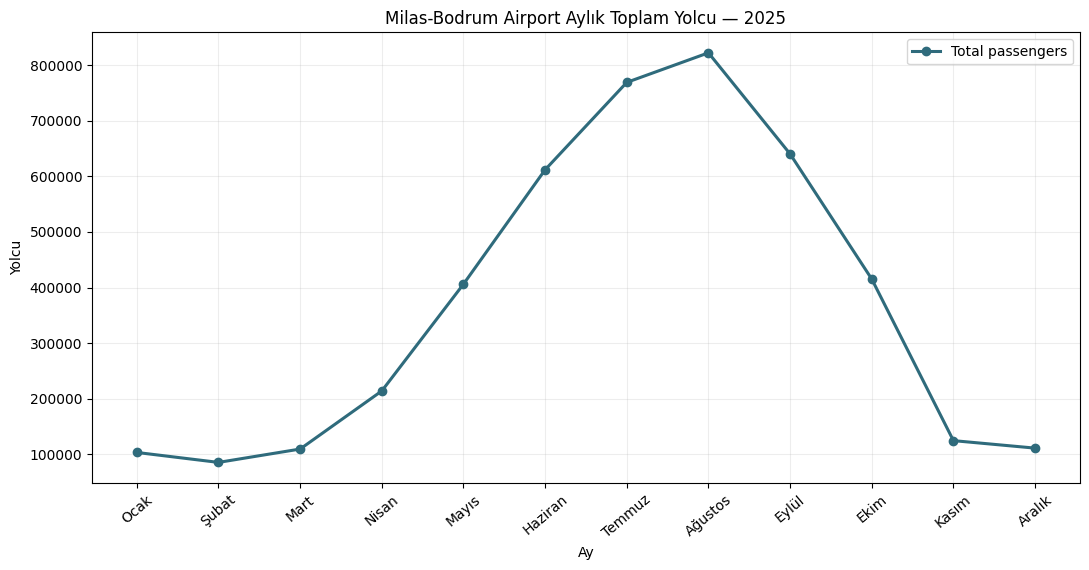

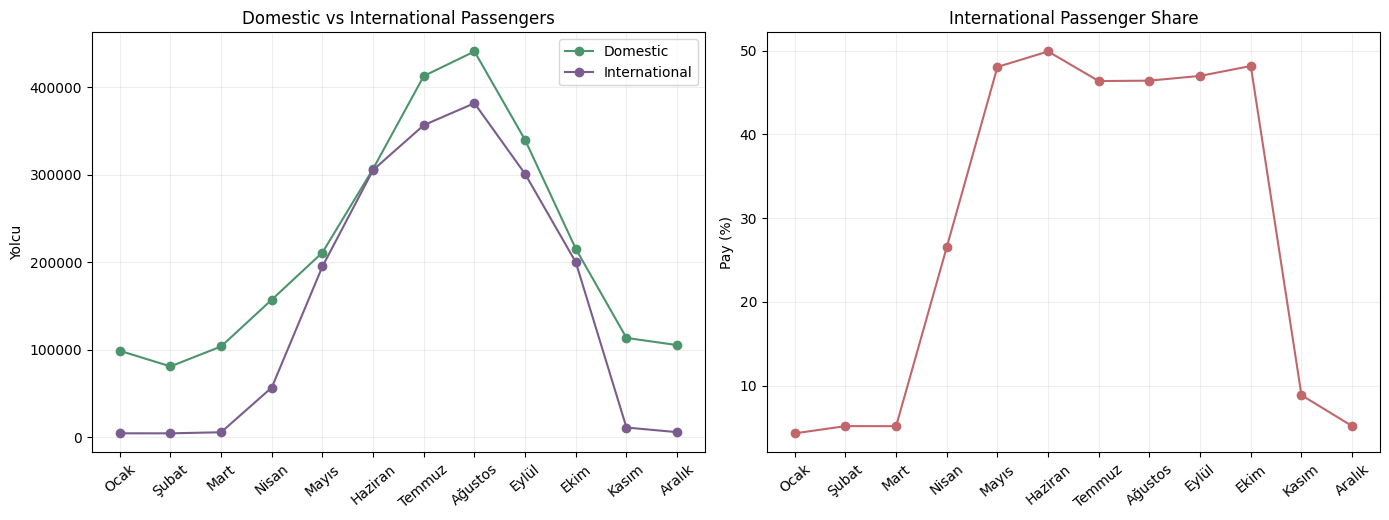

,year,monthly_observation_n,airport_annual_total_passengers,airport_peak_to_low_ratio,airport_top3_month_share_pct,airport_top4_month_share_pct,airport_total_cv,airport_international_cv,airport_domestic_cv,airport_hhi_seasonality
0,2025,12,4412884,9.6377,50.5813,64.4496,0.7652,1.0088,0.5996,0.1281


In [8]:
monthly_lines(
    joint, ["airport_total_passengers"], ["Total passengers"], [PRIMARY],
    "Milas-Bodrum Airport Aylık Toplam Yolcu — 2025", "Yolcu", "01_airport_monthly_passengers.png",
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.3))
axes[0].plot(joint["month_name_tr"], joint["airport_domestic_passengers"], marker="o", color=SECONDARY, label="Domestic")
axes[0].plot(joint["month_name_tr"], joint["airport_international_passengers"], marker="o", color=PURPLE, label="International")
axes[0].set(title="Domestic vs International Passengers", ylabel="Yolcu"); axes[0].legend(); axes[0].grid(alpha=0.2)
axes[1].plot(joint["month_name_tr"], joint["airport_international_share_pct"], marker="o", color=ACCENT)
axes[1].set(title="International Passenger Share", ylabel="Pay (%)"); axes[1].grid(alpha=0.2)
for ax in axes: ax.tick_params(axis="x", rotation=40)
save_fig(fig, "02_airport_domestic_international.png")

airport_seasonality = airport_seasonality_metrics(joint)
display(airport_seasonality)


In [9]:
airport_peak_row = joint.loc[joint["airport_total_passengers"].idxmax()]
airport_domestic_peak_row = joint.loc[joint["airport_domestic_passengers"].idxmax()]
airport_international_peak_row = joint.loc[joint["airport_international_passengers"].idxmax()]
airport_share_peak_row = joint.loc[joint["airport_international_share_pct"].idxmax()]
display(Markdown(
    f"**Bulgu:** Airport total, domestic ve international passenger zirvesi "
    f"{airport_peak_row.month_name_tr} ayında ({int(airport_peak_row.airport_total_passengers):,} total). "
    f"International passenger share en yüksek {airport_share_peak_row.month_name_tr} ayında "
    f"%{airport_share_peak_row.airport_international_share_pct:.1f}. Top 3 ay yıllık airport yolcusunun "
    f"%{airport_seasonality.iloc[0].airport_top3_month_share_pct:.1f}'ini oluşturur."
))


**Bulgu:** Airport total, domestic ve international passenger zirvesi Ağustos ayında (822,443 total). International passenger share en yüksek Haziran ayında %49.9. Top 3 ay yıllık airport yolcusunun %50.6'ini oluşturur.

### 7. Total airport × total tourism normalized seasonal alignment

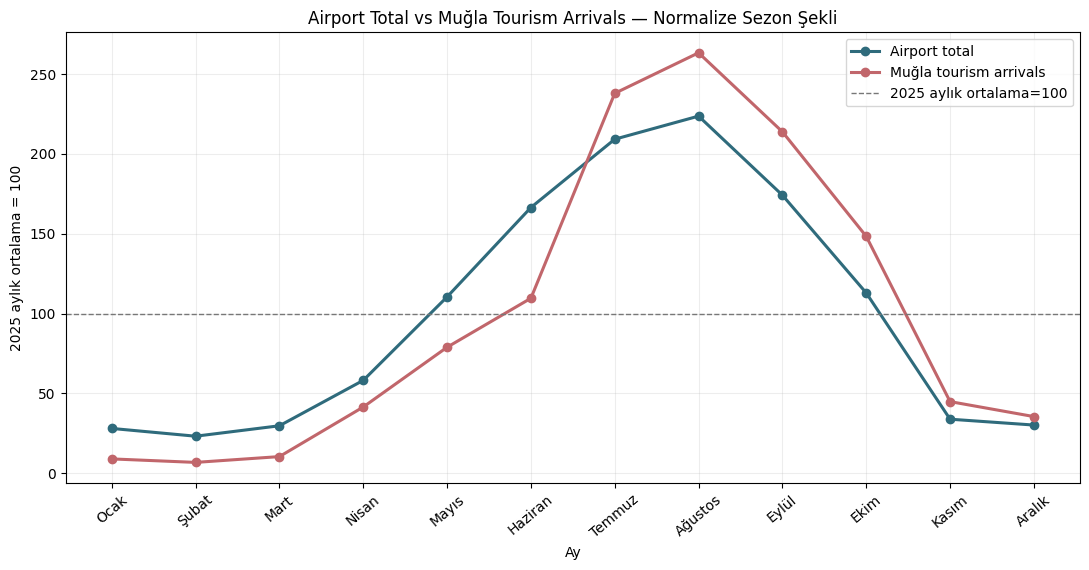

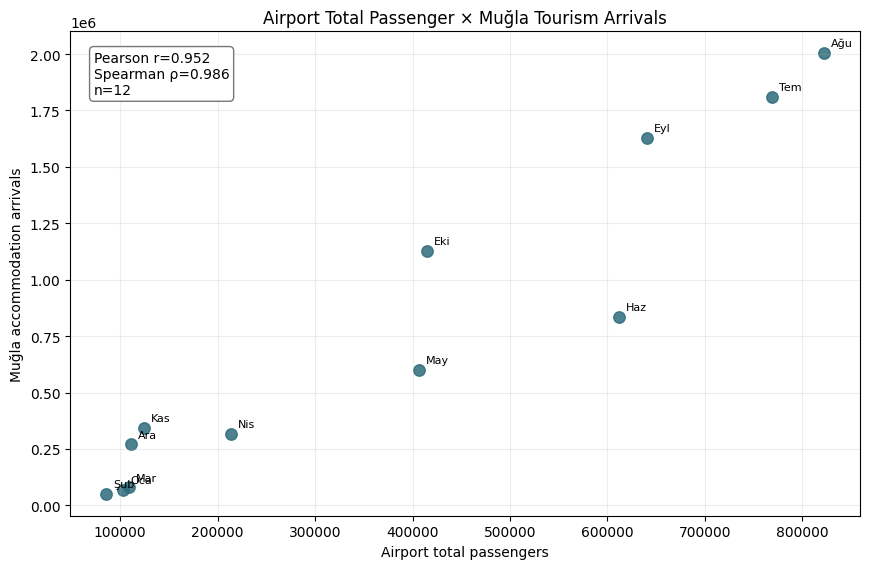

In [10]:
monthly_lines(
    joint, ["airport_total_index", "tourism_total_arrivals_index"],
    ["Airport total", "Muğla tourism arrivals"], [PRIMARY, ACCENT],
    "Airport Total vs Muğla Tourism Arrivals — Normalize Sezon Şekli",
    "2025 aylık ortalama = 100", "03_airport_vs_tourism_normalized.png", mean_line=True,
)
total_relation = labeled_scatter(
    joint, "airport_total_passengers", "tourism_total_arrivals",
    "Airport Total Passenger × Muğla Tourism Arrivals",
    "Airport total passengers", "Muğla accommodation arrivals",
    "06_airport_total_vs_tourism_scatter.png",
)


### 8. International airport × foreign tourism

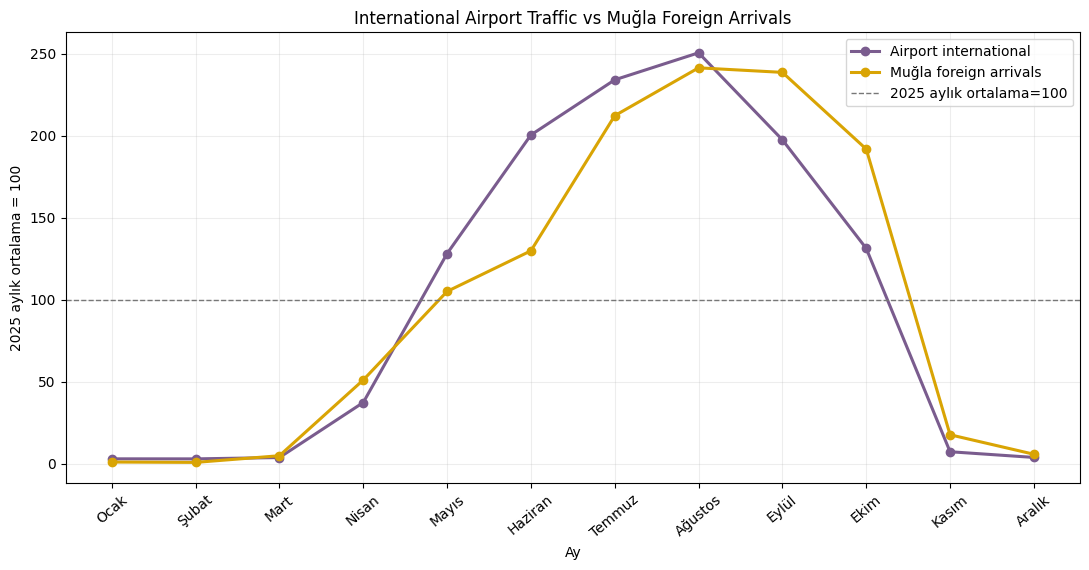

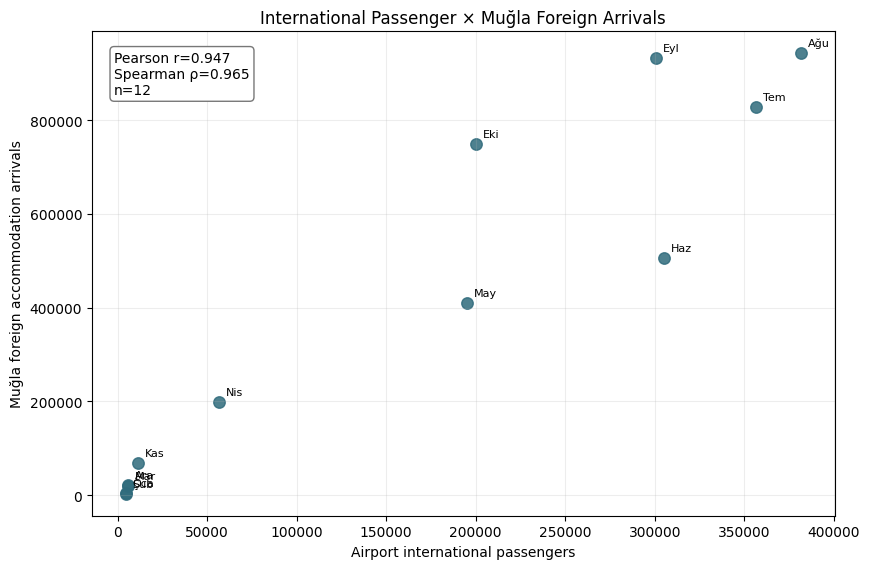

In [11]:
monthly_lines(
    joint, ["airport_international_index", "tourism_foreign_index"],
    ["Airport international", "Muğla foreign arrivals"], [PURPLE, HIGHLIGHT],
    "International Airport Traffic vs Muğla Foreign Arrivals",
    "2025 aylık ortalama = 100", "04_international_vs_foreign_normalized.png", mean_line=True,
)
international_relation = labeled_scatter(
    joint, "airport_international_passengers", "tourism_foreign_arrivals",
    "International Passenger × Muğla Foreign Arrivals",
    "Airport international passengers", "Muğla foreign accommodation arrivals",
    "07_international_vs_foreign_scatter.png",
)


Yüksek co-movement, international airport passengers'ın foreign tourist olduğu anlamına
gelmez. İki seri farklı evrenlerden gelir ve ortak sezon etkilerine birlikte tepki verebilir.


### 9. Domestic airport × domestic tourism

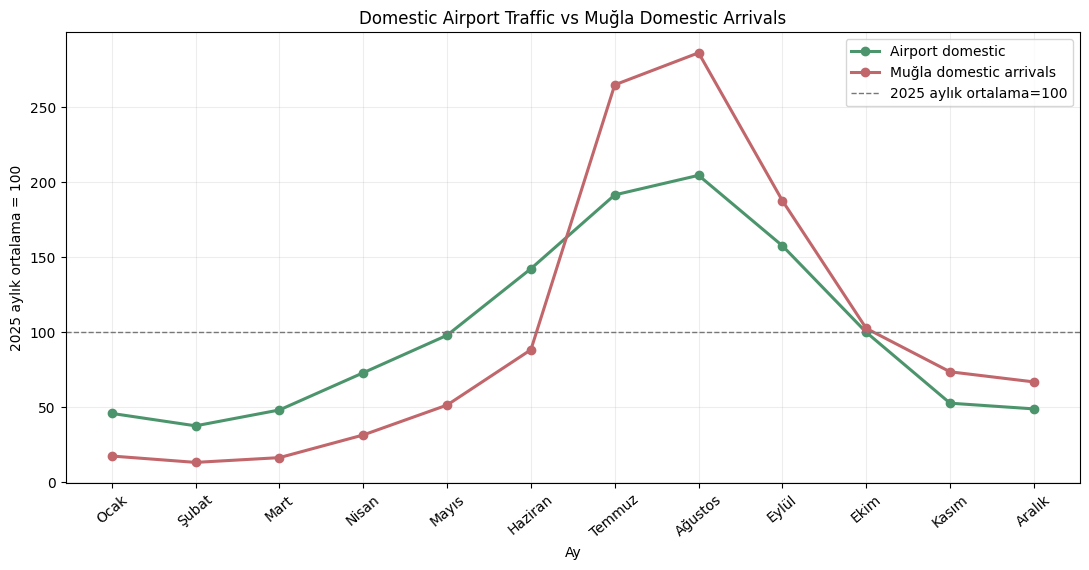

,metric_x,metric_y,n,pearson_r,pearson_p_value,spearman_rho,spearman_p_value
0,airport_domestic_passengers,tourism_domestic_arrivals,12,0.9269,0.0000,0.9301,0.0000


In [12]:
monthly_lines(
    joint, ["airport_domestic_index", "tourism_domestic_index"],
    ["Airport domestic", "Muğla domestic arrivals"], [SECONDARY, ACCENT],
    "Domestic Airport Traffic vs Muğla Domestic Arrivals",
    "2025 aylık ortalama = 100", "05_domestic_vs_domestic_normalized.png", mean_line=True,
)
domestic_relation = correlation_pair(joint, "airport_domestic_passengers", "tourism_domestic_arrivals")
display(pd.DataFrame([domestic_relation]))


### 10. Airport × overnights ve occupancy

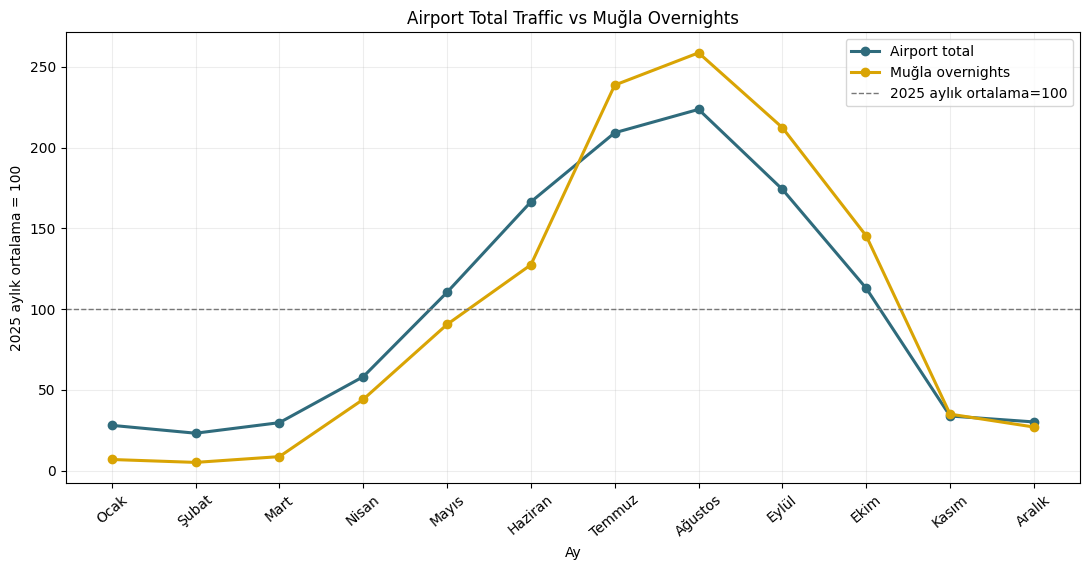

,metric_x,metric_y,n,pearson_r,pearson_p_value,spearman_rho,spearman_p_value
0,airport_total_passengers,tourism_total_overnights,12,0.9729,0.0000,0.9930,0.0000


In [13]:
monthly_lines(
    joint, ["airport_total_index", "tourism_overnights_index"],
    ["Airport total", "Muğla overnights"], [PRIMARY, HIGHLIGHT],
    "Airport Total Traffic vs Muğla Overnights",
    "2025 aylık ortalama = 100", "08_airport_vs_overnights.png", mean_line=True,
)
overnight_relation = correlation_pair(joint, "airport_total_passengers", "tourism_total_overnights")
display(pd.DataFrame([overnight_relation]))


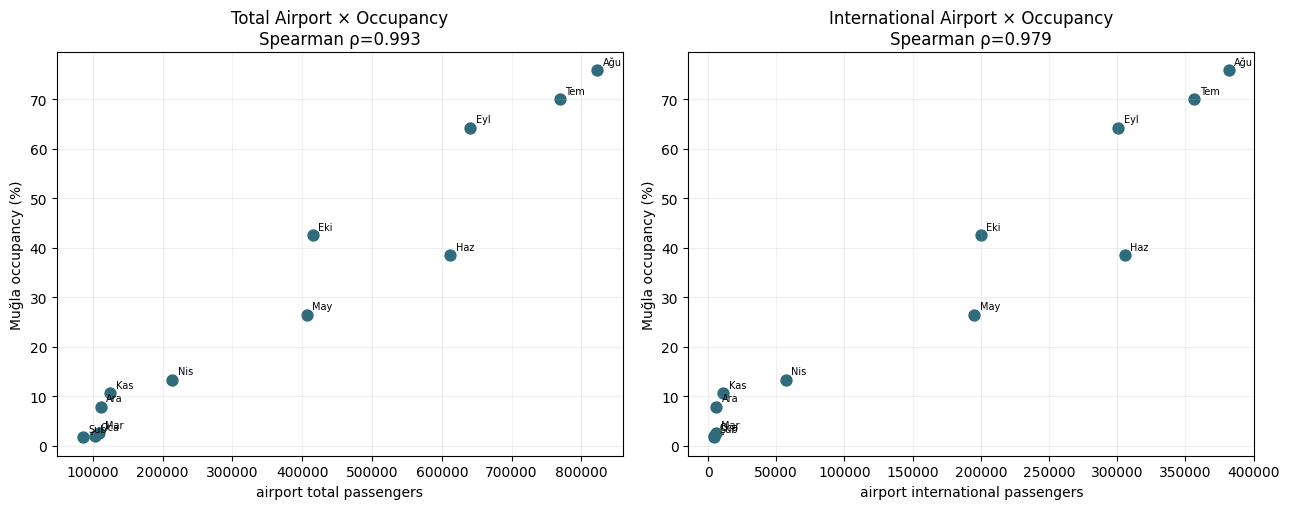

,metric_x,metric_y,n,pearson_r,pearson_p_value,spearman_rho,spearman_p_value
0,airport_total_passengers,tourism_occupancy_rate_pct,12,0.9736,0.0000,0.9930,0.0000
1,airport_international_passengers,tourism_occupancy_rate_pct,12,0.9619,0.0000,0.9790,0.0000


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
occupancy_relations = []
for ax, x, title in [
    (axes[0], "airport_total_passengers", "Total Airport × Occupancy"),
    (axes[1], "airport_international_passengers", "International Airport × Occupancy"),
]:
    ax.scatter(joint[x], joint["tourism_occupancy_rate_pct"], color=PRIMARY, s=62)
    relation = correlation_pair(joint, x, "tourism_occupancy_rate_pct")
    occupancy_relations.append(relation)
    for row in joint.itertuples():
        ax.annotate(str(row.month_name_tr)[:3], (getattr(row, x), row.tourism_occupancy_rate_pct),
                    xytext=(4, 4), textcoords="offset points", fontsize=7)
    ax.set(title=f"{title}\nSpearman ρ={relation['spearman_rho']:.3f}", xlabel=x.replace("_", " "), ylabel="Muğla occupancy (%)")
    ax.grid(alpha=0.2)
save_fig(fig, "09_airport_vs_occupancy.png")
display(pd.DataFrame(occupancy_relations))


Occupancy, yalnız arrivals veya airport trafiğinden türemez; açık tesis/oda-yatak arzı ve
kapasite kullanılabilirliği gibi faktörlerden etkilenebilir.


### 11. Peak month alignment ve ay farkları

In [15]:
peaks = peak_alignment(joint)
display(peaks)


,metric,source_column,peak_period,peak_month,peak_month_number,peak_value,month_difference_vs_airport_total_peak,month_difference_vs_airport_international_peak
0,airport_total,airport_total_passengers,2025-08,Ağustos,8,"822,443.0000",0,0
1,airport_domestic,airport_domestic_passengers,2025-08,Ağustos,8,"440,795.0000",0,0
2,airport_international,airport_international_passengers,2025-08,Ağustos,8,"381,648.0000",0,0
3,tourism_total_arrivals,tourism_total_arrivals,2025-08,Ağustos,8,"2,003,174.0000",0,0
4,tourism_domestic_arrivals,tourism_domestic_arrivals,2025-08,Ağustos,8,"1,061,003.0000",0,0
5,tourism_foreign_arrivals,tourism_foreign_arrivals,2025-08,Ağustos,8,"942,171.0000",0,0
6,tourism_overnights,tourism_total_overnights,2025-08,Ağustos,8,"5,317,523.0000",0,0
7,tourism_occupancy,tourism_occupancy_rate_pct,2025-08,Ağustos,8,75.8000,0,0


In [16]:
tourism_peak = peaks.loc[peaks["metric"].eq("tourism_total_arrivals")].iloc[0]
foreign_peak = peaks.loc[peaks["metric"].eq("tourism_foreign_arrivals")].iloc[0]
overnight_peak = peaks.loc[peaks["metric"].eq("tourism_overnights")].iloc[0]
display(Markdown(
    f"**Bulgu:** Airport total peak ile tourism total arrivals peak ay farkı "
    f"{int(tourism_peak.month_difference_vs_airport_total_peak)}; international airport peak ile foreign "
    f"arrival peak farkı {int(foreign_peak.month_difference_vs_airport_international_peak)}; airport total "
    f"peak ile overnights peak farkı {int(overnight_peak.month_difference_vs_airport_total_peak)} aydır."
))


**Bulgu:** Airport total peak ile tourism total arrivals peak ay farkı 0; international airport peak ile foreign arrival peak farkı 0; airport total peak ile overnights peak farkı 0 aydır.

### 12. Lag 0 / lag 1 keşifsel hizalama

In [17]:
lag_table = lag_correlations(joint)
display(lag_table)


,metric_pair,airport_metric,tourism_metric,lag_months,alignment,n,pearson_r,spearman_rho,p_value,note
0,total airport vs total tourism,airport_total_passengers,tourism_total_arrivals,0,airport_t vs tourism_t,12,0.9524,0.9860,0.0000,Exploratory only; lag is not predictive or causal.
1,total airport vs total tourism,airport_total_passengers,tourism_total_arrivals,1,airport_t vs tourism_t+1,11,0.9190,0.9091,0.0001,Exploratory only; lag is not predictive or causal.
2,international airport vs foreign tourism,airport_international_passengers,tourism_foreign_arrivals,0,airport_t vs tourism_t,12,0.9467,0.9650,0.0000,Exploratory only; lag is not predictive or causal.
3,international airport vs foreign tourism,airport_international_passengers,tourism_foreign_arrivals,1,airport_t vs tourism_t+1,11,0.8991,0.9091,0.0001,Exploratory only; lag is not predictive or causal.
4,domestic airport vs domestic tourism,airport_domestic_passengers,tourism_domestic_arrivals,0,airport_t vs tourism_t,12,0.9269,0.9301,0.0000,Exploratory only; lag is not predictive or causal.
5,domestic airport vs domestic tourism,airport_domestic_passengers,tourism_domestic_arrivals,1,airport_t vs tourism_t+1,11,0.8472,0.9273,0.0000,Exploratory only; lag is not predictive or causal.


In [18]:
lag_comparison = lag_table.pivot(index="metric_pair", columns="lag_months", values="spearman_rho").rename(columns={0: "lag0_rho", 1: "lag1_rho"})
lag_comparison["lag1_minus_lag0"] = lag_comparison["lag1_rho"] - lag_comparison["lag0_rho"]
display(lag_comparison)
display(Markdown(
    "**Yorum:** Lag 1, `airport_t` ile `tourism_t+1` hizalamasıdır ve 11 gözleme dayanır. "
    "Bu karşılaştırma predictive lead/lag veya nedensellik kanıtı değildir."
))


lag_months,lag0_rho,lag1_rho,lag1_minus_lag0
metric_pair,,,
domestic airport vs domestic tourism,0.9301,0.9273,-0.0028
international airport vs foreign tourism,0.9650,0.9091,-0.0559
total airport vs total tourism,0.9860,0.9091,-0.0769


**Yorum:** Lag 1, `airport_t` ile `tourism_t+1` hizalamasıdır ve 11 gözleme dayanır. Bu karşılaştırma predictive lead/lag veya nedensellik kanıtı değildir.

### 13. International share × foreign tourism share

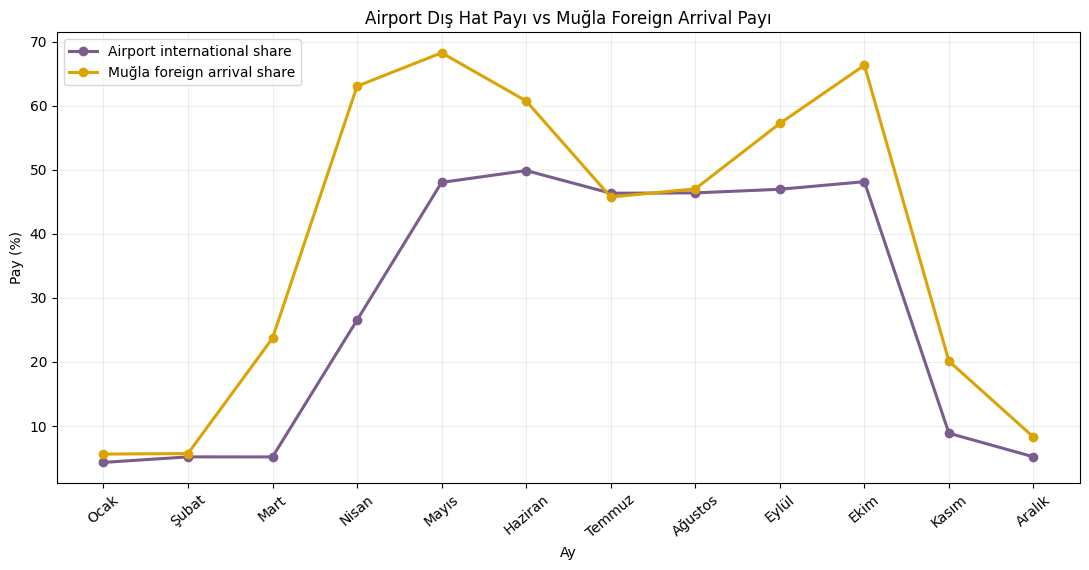

,period,month_name_tr,airport_international_share_pct,tourism_foreign_share_pct,share_gap_pp
0,2025-01,Ocak,4.3232,5.6210,-1.2978
1,2025-02,Şubat,5.1830,5.7048,-0.5218
2,2025-03,Mart,5.1789,23.7194,-18.5405
3,2025-04,Nisan,26.5434,63.0672,-36.5239
4,2025-05,Mayıs,48.0412,68.2758,-20.2346
5,2025-06,Haziran,49.8904,60.7553,-10.8650
6,2025-07,Temmuz,46.3511,45.7572,0.5939
7,2025-08,Ağustos,46.4042,47.0339,-0.6297
8,2025-09,Eylül,46.9698,57.2479,-10.2782
9,2025-10,Ekim,48.1525,66.3330,-18.1805


**Bulgu:** İki oran arasındaki en büyük mutlak fark Nisan ayında -36.5 yüzde puandır. Bu metrik conversion gap değildir.

In [19]:
monthly_lines(
    joint, ["airport_international_share_pct", "tourism_foreign_share_pct"],
    ["Airport international share", "Muğla foreign arrival share"], [PURPLE, HIGHLIGHT],
    "Airport Dış Hat Payı vs Muğla Foreign Arrival Payı",
    "Pay (%)", "10_international_share_vs_foreign_share.png",
)
share_gap_extreme = joint.loc[joint["share_gap_pp"].abs().idxmax()]
display(joint[["period", "month_name_tr", "airport_international_share_pct", "tourism_foreign_share_pct", "share_gap_pp"]])
display(Markdown(
    f"**Bulgu:** İki oran arasındaki en büyük mutlak fark {share_gap_extreme.month_name_tr} ayında "
    f"{share_gap_extreme.share_gap_pp:.1f} yüzde puandır. Bu metrik conversion gap değildir."
))


### 14. Proxy ratios ve tourism-derived season groups

In [20]:
proxy_columns = [
    "period", "month_name_tr", "tourism_arrivals_per_airport_passenger_proxy_ratio",
    "foreign_arrivals_per_international_airport_passenger_proxy_ratio",
    "domestic_arrivals_per_domestic_airport_passenger_proxy_ratio",
]
display(joint[proxy_columns])
season_table = season_summary(joint)
display(season_table)


,period,month_name_tr,tourism_arrivals_per_airport_passenger_proxy_ratio,foreign_arrivals_per_international_airport_passenger_proxy_ratio,domestic_arrivals_per_domestic_airport_passenger_proxy_ratio
0,2025-01,Ocak,0.6624,0.8613,0.6535
1,2025-02,Şubat,0.6066,0.6676,0.6032
2,2025-03,Mart,0.7261,3.3257,0.5842
3,2025-04,Nisan,1.4755,3.5057,0.7418
4,2025-05,Mayıs,1.4783,2.1009,0.9026
5,2025-06,Haziran,1.3625,1.6592,1.0671
6,2025-07,Temmuz,2.3531,2.3229,2.3791
7,2025-08,Ağustos,2.4356,2.4687,2.4070
8,2025-09,Eylül,2.5404,3.0963,2.0480
9,2025-10,Ekim,2.7183,3.7446,1.7651


,season_group,month_count,avg_airport_total,avg_airport_domestic,avg_airport_international,avg_airport_international_share_pct,avg_tourism_arrivals,avg_foreign_arrivals,avg_overnights,avg_occupancy
0,LOW,4,"102,237.2500","97,159.2500","5,078.0000",4.9689,"117,403.5000","11,993.5000","245,781.2500",3.5250
1,PEAK,4,"661,838.0000","352,099.0000","309,739.0000",46.9694,"1,642,239.5000","862,636.0000","4,394,380.2500",63.1250
2,SHOULDER,4,"339,145.7500","197,075.2500","142,070.5000",33.3379,"522,823.7500","296,082.5000","1,527,211.0000",22.2250


Proxy ratio >1 hata değildir; airport passenger ve accommodation arrival aynı kişi/universe
değildir. `season_group`, 09 notebookunda Muğla tourism arrivals tertillerinden türetilmiştir; airport
aylarından bağımsız bir sezon etiketi değildir.


### 15. Monthly normalized divergence

,period,month,airport_total_index,tourism_total_index,total_index_gap,airport_international_index,tourism_foreign_index,international_foreign_gap,abs_total_gap,abs_international_foreign_gap
5,2025-06,Haziran,166.4196,109.5959,56.8237,200.4815,129.8174,70.6641,56.8237,70.6641
8,2025-09,Eylül,174.1449,213.8313,-39.6864,197.5070,238.6632,-41.1562,39.6864,41.1562
7,2025-08,Ağustos,223.6478,263.2907,-39.6429,250.5965,241.4354,9.1611,39.6429,9.1611
9,2025-10,Ekim,112.9210,148.3642,-35.4432,131.2945,191.8727,-60.5783,35.4432,60.5783
4,2025-05,Mayıs,110.4451,78.9150,31.5300,128.1191,105.0463,23.0727,31.5300,23.0727
6,2025-07,Temmuz,209.1835,237.9163,-28.7328,234.1213,212.2455,21.8759,28.7328,21.8759
2,2025-03,Mart,29.7403,10.4382,19.3021,3.7191,4.8271,-1.1080,19.3021,1.1080
0,2025-01,Ocak,28.0723,8.9884,19.0838,2.9305,0.9850,1.9454,19.0838,1.9454
3,2025-04,Nisan,58.1750,41.4883,16.6867,37.2860,51.0133,-13.7273,16.6867,13.7273
1,2025-02,Şubat,23.2055,6.8036,16.4019,2.9042,0.7567,2.1475,16.4019,2.1475


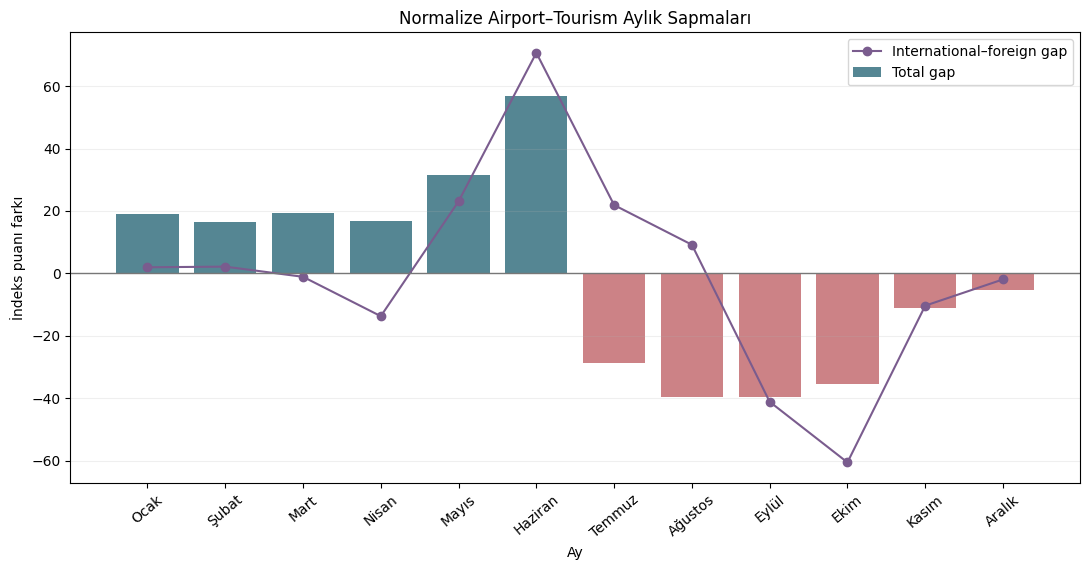

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/airport_tourism/11_monthly_divergence.png')

In [21]:
divergence = joint[[
    "period", "month_name_tr", "airport_total_index", "tourism_total_arrivals_index",
    "total_index_gap", "airport_international_index", "tourism_foreign_index",
    "international_foreign_index_gap",
]].rename(columns={
    "month_name_tr": "month", "tourism_total_arrivals_index": "tourism_total_index",
    "international_foreign_index_gap": "international_foreign_gap",
})
divergence["abs_total_gap"] = divergence["total_index_gap"].abs()
divergence["abs_international_foreign_gap"] = divergence["international_foreign_gap"].abs()
display(divergence.sort_values("abs_total_gap", ascending=False))

fig, ax = plt.subplots(figsize=(11, 5.8))
ax.bar(joint["month_name_tr"], joint["total_index_gap"], color=np.where(joint["total_index_gap"].ge(0), PRIMARY, ACCENT), alpha=0.82, label="Total gap")
ax.plot(joint["month_name_tr"], joint["international_foreign_index_gap"], marker="o", color=PURPLE, label="International–foreign gap")
ax.axhline(0, color=NEUTRAL, linewidth=1)
ax.set(title="Normalize Airport–Tourism Aylık Sapmaları", xlabel="Ay", ylabel="İndeks puanı farkı")
ax.tick_params(axis="x", rotation=40); ax.grid(axis="y", alpha=0.2); ax.legend()
save_fig(fig, "11_monthly_divergence.png")


In [22]:
largest_total_divergence = divergence.loc[divergence["abs_total_gap"].idxmax()]
largest_international_divergence = divergence.loc[divergence["abs_international_foreign_gap"].idxmax()]
display(Markdown(
    f"**Bulgu:** En büyük mutlak total index ayrışması {largest_total_divergence['month']} "
    f"({largest_total_divergence.total_index_gap:.1f} indeks puanı); international–foreign ayrışması "
    f"{largest_international_divergence['month']} ({largest_international_divergence.international_foreign_gap:.1f}) "
    f"ayında görülür. Neden atfedilmez."
))


**Bulgu:** En büyük mutlak total index ayrışması Haziran (56.8 indeks puanı); international–foreign ayrışması Haziran (70.7) ayında görülür. Neden atfedilmez.

### 16. Cross-domain correlation table ve heatmap

,metric_x,metric_y,n,pearson_r,pearson_p_value,spearman_rho,spearman_p_value,note
3,airport_domestic_passengers,tourism_total_overnights,12,0.9763,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
4,airport_domestic_passengers,tourism_occupancy_rate_pct,12,0.9765,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
13,airport_total_passengers,tourism_total_overnights,12,0.9729,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
14,airport_total_passengers,tourism_occupancy_rate_pct,12,0.9736,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
1,airport_domestic_passengers,tourism_foreign_arrivals,12,0.9312,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."
2,airport_domestic_passengers,tourism_total_arrivals,12,0.9615,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."
11,airport_total_passengers,tourism_foreign_arrivals,12,0.9444,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."
12,airport_total_passengers,tourism_total_arrivals,12,0.9524,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."
8,airport_international_passengers,tourism_total_overnights,12,0.9608,0.0000,0.9790,0.0000,"Cross-domain co-movement only; n=12, not causal."
9,airport_international_passengers,tourism_occupancy_rate_pct,12,0.9619,0.0000,0.9790,0.0000,"Cross-domain co-movement only; n=12, not causal."


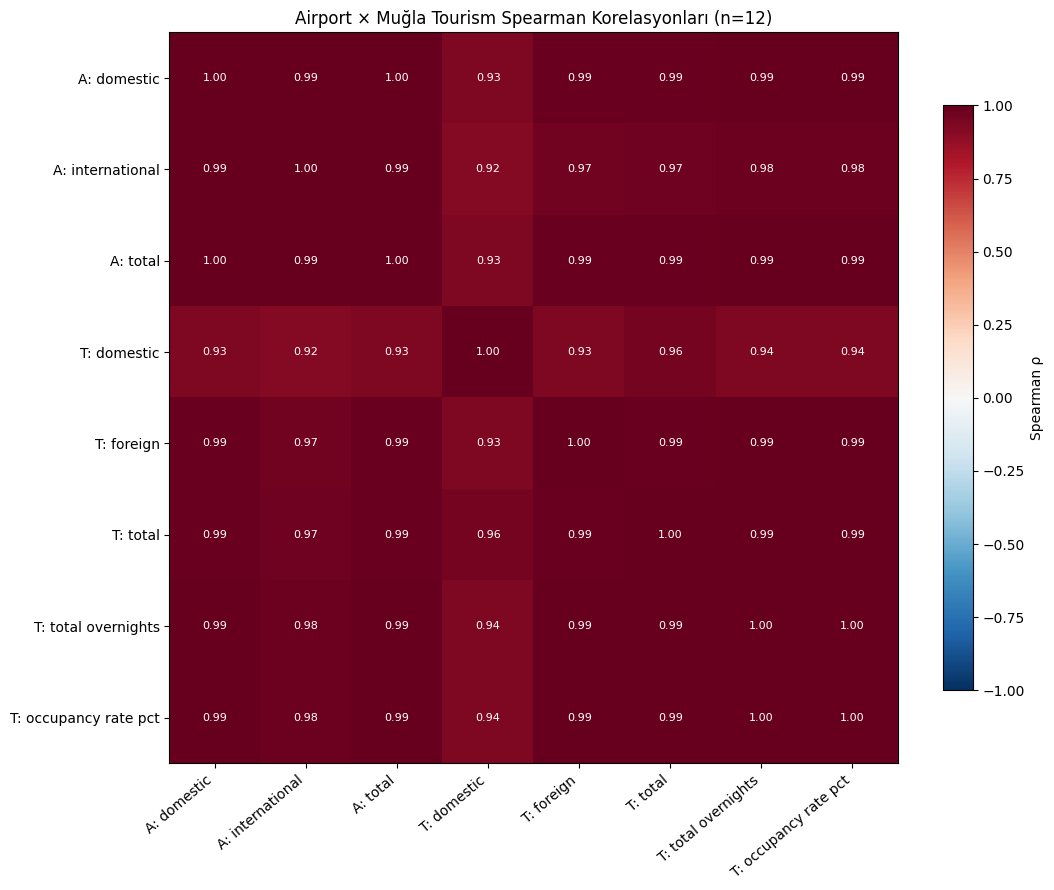

PosixPath('/Users/nihatkutukoglu/Downloads/bodrum-otel/reports/figures/airport_tourism/12_correlation_heatmap.png')

In [23]:
correlations = cross_domain_correlations(joint)
display(correlations.sort_values("spearman_rho", ascending=False))

matrix_columns = [
    "airport_domestic_passengers", "airport_international_passengers", "airport_total_passengers",
    "tourism_domestic_arrivals", "tourism_foreign_arrivals", "tourism_total_arrivals",
    "tourism_total_overnights", "tourism_occupancy_rate_pct",
]
spearman_matrix = joint[matrix_columns].corr(method="spearman")
fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(spearman_matrix.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
labels = [c.replace("airport_", "A: ").replace("tourism_", "T: ").replace("_passengers", "").replace("_arrivals", "").replace("_", " ") for c in matrix_columns]
ax.set_xticks(range(len(labels)), labels, rotation=40, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.set_title("Airport × Muğla Tourism Spearman Korelasyonları (n=12)")
for i in range(len(labels)):
    for j in range(len(labels)):
        value = spearman_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(value) > 0.65 else "black")
fig.colorbar(image, ax=ax, shrink=0.8, label="Spearman ρ")
save_fig(fig, "12_correlation_heatmap.png")


In [24]:
strongest_cross_domain = correlations.reindex(correlations["spearman_rho"].abs().sort_values(ascending=False).index).head(8)
display(strongest_cross_domain)
display(Markdown(
    "**Not:** Airport total = domestic + international; tourism total = domestic + foreign. Aynı "
    "domain içindeki total bileşen korelasyonları matematiksel bağımlılık içerir. Raporlanan tablo "
    "yalnız airport–tourism cross-domain çiftlerini içerir."
))


,metric_x,metric_y,n,pearson_r,pearson_p_value,spearman_rho,spearman_p_value,note
3,airport_domestic_passengers,tourism_total_overnights,12,0.9763,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
4,airport_domestic_passengers,tourism_occupancy_rate_pct,12,0.9765,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
13,airport_total_passengers,tourism_total_overnights,12,0.9729,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
14,airport_total_passengers,tourism_occupancy_rate_pct,12,0.9736,0.0000,0.9930,0.0000,"Cross-domain co-movement only; n=12, not causal."
1,airport_domestic_passengers,tourism_foreign_arrivals,12,0.9312,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."
2,airport_domestic_passengers,tourism_total_arrivals,12,0.9615,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."
11,airport_total_passengers,tourism_foreign_arrivals,12,0.9444,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."
12,airport_total_passengers,tourism_total_arrivals,12,0.9524,0.0000,0.9860,0.0000,"Cross-domain co-movement only; n=12, not causal."


**Not:** Airport total = domestic + international; tourism total = domestic + foreign. Aynı domain içindeki total bileşen korelasyonları matematiksel bağımlılık içerir. Raporlanan tablo yalnız airport–tourism cross-domain çiftlerini içerir.

### 17. Bodrum annual ve Destination Intelligence bağlamı

In [25]:
context_rows = [{
    "airport_2025_total_passengers": airport_annual_sum,
    "airport_scope": "Milas-Bodrum regional gateway passengers",
    "mugla_2025_monthly_tourism_arrivals_sum": int(joint["tourism_total_arrivals"].sum()),
    "tourism_scope": "Muğla province accommodation arrivals",
    "direct_ratio_interpretation_allowed": False,
}]
if bodrum_profile is not None:
    context_rows[0]["bodrum_2025_annual_accommodation_arrivals"] = int(bodrum_profile.loc[0, "total_arrivals"])
    context_rows[0]["bodrum_scope"] = "Bodrum district annual accommodation arrivals"
if destination_context is not None:
    context_rows[0]["hotel_snapshot_year"] = 2026
    context_rows[0]["destination_monthly_join_performed"] = False
display(pd.DataFrame(context_rows))


,airport_2025_total_passengers,airport_scope,mugla_2025_monthly_tourism_arrivals_sum,tourism_scope,direct_ratio_interpretation_allowed,bodrum_2025_annual_accommodation_arrivals,bodrum_scope,hotel_snapshot_year,destination_monthly_join_performed
0,4412884,Milas-Bodrum regional gateway passengers,9129867,Muğla province accommodation arrivals,False,2823425,Bodrum district annual accommodation arrivals,2026,False


Bodrum annual arrivals ve airport annual passengers yalnız KPI olarak yan yana gösterilir;
birebir ratio/conversion olarak yorumlanmaz. 14 destination monthly airport/tourism serisiyle merge
edilmez; böyle bir monthly destination demand katmanı mevcut değildir.


### 18. Raporların kaydedilmesi

In [26]:
output_paths = {
    "joint_monthly": PROCESSED_OUTPUT,
    "input_summary": REPORTS_DIR / "airport_tourism_input_summary.csv",
    "quality_checks": REPORTS_DIR / "airport_tourism_quality_checks.csv",
    "airport_seasonality": REPORTS_DIR / "airport_seasonality_metrics.csv",
    "peaks": REPORTS_DIR / "airport_tourism_peak_alignment.csv",
    "correlations": REPORTS_DIR / "airport_tourism_correlations.csv",
    "lag_correlations": REPORTS_DIR / "airport_tourism_lag_correlations.csv",
    "season_summary": REPORTS_DIR / "airport_tourism_season_summary.csv",
    "divergence": REPORTS_DIR / "airport_tourism_divergence_months.csv",
}
joint.to_csv(output_paths["joint_monthly"], index=False, encoding="utf-8-sig")
input_summary.to_csv(output_paths["input_summary"], index=False, encoding="utf-8-sig")
pd.concat([
    airport_checks.assign(dataset="airport"), tourism_checks.assign(dataset="tourism")
], ignore_index=True).to_csv(output_paths["quality_checks"], index=False, encoding="utf-8-sig")
airport_seasonality.to_csv(output_paths["airport_seasonality"], index=False, encoding="utf-8-sig")
peaks.to_csv(output_paths["peaks"], index=False, encoding="utf-8-sig")
correlations.to_csv(output_paths["correlations"], index=False, encoding="utf-8-sig")
lag_table.to_csv(output_paths["lag_correlations"], index=False, encoding="utf-8-sig")
season_table.to_csv(output_paths["season_summary"], index=False, encoding="utf-8-sig")
divergence.to_csv(output_paths["divergence"], index=False, encoding="utf-8-sig")


## Temel Bulgular

In [27]:
total_lag0 = lag_table.loc[lag_table["metric_pair"].eq("total airport vs total tourism") & lag_table["lag_months"].eq(0)].iloc[0]
total_lag1 = lag_table.loc[lag_table["metric_pair"].eq("total airport vs total tourism") & lag_table["lag_months"].eq(1)].iloc[0]
international_lag0 = lag_table.loc[lag_table["metric_pair"].eq("international airport vs foreign tourism") & lag_table["lag_months"].eq(0)].iloc[0]
international_lag1 = lag_table.loc[lag_table["metric_pair"].eq("international airport vs foreign tourism") & lag_table["lag_months"].eq(1)].iloc[0]
domestic_lag0 = lag_table.loc[lag_table["metric_pair"].eq("domestic airport vs domestic tourism") & lag_table["lag_months"].eq(0)].iloc[0]
occupancy_total = occupancy_relations[0]

findings = [
    f"Milas-Bodrum Airport 2025 peak total passenger ayı {airport_peak_row.month_name_tr}: {int(airport_peak_row.airport_total_passengers):,}.",
    f"International passenger zirvesi {airport_international_peak_row.month_name_tr}: {int(airport_international_peak_row.airport_international_passengers):,}.",
    f"Muğla tourism total arrival peak ayı {tourism_peak.peak_month}; airport peak ile ay farkı {int(tourism_peak.month_difference_vs_airport_total_peak)}.",
    f"Muğla foreign arrival peak ayı {foreign_peak.peak_month}; international airport peak ile ay farkı {int(foreign_peak.month_difference_vs_airport_international_peak)}.",
    f"Airport total passengers ile Muğla tourism total arrivals Spearman ρ={total_relation['spearman_rho']:.3f} (n=12).",
    f"Airport international passengers ile Muğla foreign arrivals Spearman ρ={international_relation['spearman_rho']:.3f} (n=12).",
    f"Airport domestic passengers ile Muğla domestic arrivals Spearman ρ={domestic_relation['spearman_rho']:.3f} (n=12).",
    f"Airport total passengers ile Muğla overnights Spearman ρ={overnight_relation['spearman_rho']:.3f} (n=12).",
    f"Airport total passengers ile Muğla occupancy Spearman ρ={occupancy_total['spearman_rho']:.3f} (n=12); occupancy supply availability'den de etkilenir.",
    f"En büyük total normalized divergence {largest_total_divergence['month']} ayında {largest_total_divergence.total_index_gap:.1f} indeks puanıdır.",
    f"Total pair için lag 0 Spearman ρ={total_lag0.spearman_rho:.3f}, lag 1 ρ={total_lag1.spearman_rho:.3f}; international–foreign için lag 0 ρ={international_lag0.spearman_rho:.3f}, lag 1 ρ={international_lag1.spearman_rho:.3f}.",
    "En önemli sınırlılık airport passenger ile accommodation arrival'ın aynı kişi, population veya grain olmamasıdır.",
]
key_findings_path = REPORTS_DIR / "airport_tourism_key_findings.txt"
key_findings_path.write_text(
    "Bodrum Hotel & Destination Intelligence — Airport × Tourism Temel Bulgular\n\n"
    + "\n".join(f"- {item}" for item in findings) + "\n",
    encoding="utf-8",
)
display(Markdown("\n".join(f"- {item}" for item in findings)))


- Milas-Bodrum Airport 2025 peak total passenger ayı Ağustos: 822,443.
- International passenger zirvesi Ağustos: 381,648.
- Muğla tourism total arrival peak ayı Ağustos; airport peak ile ay farkı 0.
- Muğla foreign arrival peak ayı Ağustos; international airport peak ile ay farkı 0.
- Airport total passengers ile Muğla tourism total arrivals Spearman ρ=0.986 (n=12).
- Airport international passengers ile Muğla foreign arrivals Spearman ρ=0.965 (n=12).
- Airport domestic passengers ile Muğla domestic arrivals Spearman ρ=0.930 (n=12).
- Airport total passengers ile Muğla overnights Spearman ρ=0.993 (n=12).
- Airport total passengers ile Muğla occupancy Spearman ρ=0.993 (n=12); occupancy supply availability'den de etkilenir.
- En büyük total normalized divergence Haziran ayında 56.8 indeks puanıdır.
- Total pair için lag 0 Spearman ρ=0.986, lag 1 ρ=0.909; international–foreign için lag 0 ρ=0.965, lag 1 ρ=0.909.
- En önemli sınırlılık airport passenger ile accommodation arrival'ın aynı kişi, population veya grain olmamasıdır.

## Analiz Sınırlılıkları

In [28]:
limitations = [
    "Airport passengers yalnız turist değildir.",
    "Tourism arrivals airport passenger ile aynı grain/population değildir ve benzersiz kişi olmayabilir.",
    "Milas-Bodrum Airport bölgesel gateway'dir; yolcular başka destinasyonlara devam edebilir.",
    "Tourism monthly data Muğla il seviyesindedir; Bodrum monthly tourism verisi değildir.",
    "Yalnızca 12 aylık gözlem vardır.",
    "Korelasyon nedensellik değildir; ortak sezon etkisi yüksek birlikte hareket üretebilir.",
    "Lag analizi predictive veya causal değildir; lag 1 yalnız 11 hizalı gözlem içerir.",
    "Occupancy açık accommodation supply ve kapasite kullanılabilirliğinden etkilenebilir.",
    "Annual hotel/Google snapshot 2026, airport ve tourism serileri 2025 tarihlidir.",
    "Farklı veri setlerinin toplama ve istatistik tanımları farklı olabilir; proxy ratio conversion değildir.",
]
limitations_path = REPORTS_DIR / "airport_tourism_limitations.txt"
limitations_path.write_text("\n".join(f"- {item}" for item in limitations) + "\n", encoding="utf-8")
display(Markdown("\n".join(f"- {item}" for item in limitations)))


- Airport passengers yalnız turist değildir.
- Tourism arrivals airport passenger ile aynı grain/population değildir ve benzersiz kişi olmayabilir.
- Milas-Bodrum Airport bölgesel gateway'dir; yolcular başka destinasyonlara devam edebilir.
- Tourism monthly data Muğla il seviyesindedir; Bodrum monthly tourism verisi değildir.
- Yalnızca 12 aylık gözlem vardır.
- Korelasyon nedensellik değildir; ortak sezon etkisi yüksek birlikte hareket üretebilir.
- Lag analizi predictive veya causal değildir; lag 1 yalnız 11 hizalı gözlem içerir.
- Occupancy açık accommodation supply ve kapasite kullanılabilirliğinden etkilenebilir.
- Annual hotel/Google snapshot 2026, airport ve tourism serileri 2025 tarihlidir.
- Farklı veri setlerinin toplama ve istatistik tanımları farklı olabilir; proxy ratio conversion değildir.

## Customer Voice Layer

Sonraki aşama veri türüne bağlıdır. Normal customer review dataset'i hazırsa
`11_review_data_audit_cleaning.ipynb`; Google Maps scraping yerine Şikayetvar corpus'u kullanılıyorsa
`11_sikayetvar_complaint_audit_cleaning.ipynb` oluşturulmalıdır. Şikayetvar verisi genel review
evreni değil, **negative customer voice / complaint corpus** olarak analiz edilmelidir.


### 19. Çalıştırma ve çıktı bütünlüğü doğrulaması

In [29]:
expected_figures = [
    "01_airport_monthly_passengers.png", "02_airport_domestic_international.png",
    "03_airport_vs_tourism_normalized.png", "04_international_vs_foreign_normalized.png",
    "05_domestic_vs_domestic_normalized.png", "06_airport_total_vs_tourism_scatter.png",
    "07_international_vs_foreign_scatter.png", "08_airport_vs_overnights.png",
    "09_airport_vs_occupancy.png", "10_international_share_vs_foreign_share.png",
    "11_monthly_divergence.png", "12_correlation_heatmap.png",
]
figure_paths = [FIGURES_DIR / name for name in expected_figures]
input_hashes_after = {path: hashlib.sha256(path.read_bytes()).hexdigest() for path in input_paths}

assert input_hashes_before == input_hashes_after
assert len(airport_raw) == 12 and airport_raw["period"].is_unique
assert len(tourism_raw) == 12 and tourism_raw["period"].is_unique
assert len(joint) == 12 and joint["period"].is_unique
assert joint["period"].tolist() == [f"2025-{month:02d}" for month in range(1, 13)]
assert airport_audited["passenger_total_difference"].eq(0).all()
assert airport_audited["cumulative_total_monthly_difference"].eq(0).all()
assert tourism_raw["arrival_total_difference"].eq(0).all()
assert np.isfinite(joint.select_dtypes(include="number")).all().all()
assert set(lag_table.loc[lag_table["lag_months"].eq(0), "n"]) == {12}
assert set(lag_table.loc[lag_table["lag_months"].eq(1), "n"]) == {11}
assert all(path.exists() and path.stat().st_size > 0 for path in output_paths.values())
assert key_findings_path.exists() and limitations_path.exists()
assert all(path.exists() and path.stat().st_size > 0 for path in figure_paths)

validation = pd.DataFrame([
    ("airport_12_months", len(airport_raw) == 12),
    ("tourism_12_months", len(tourism_raw) == 12),
    ("merge_12_rows", len(joint) == 12),
    ("unique_period", joint["period"].is_unique),
    ("passenger_totals_reconcile", airport_audited["passenger_total_difference"].eq(0).all()),
    ("cumulative_monthly_values_reconcile", airport_audited["cumulative_total_monthly_difference"].eq(0).all()),
    ("finite_numeric_outputs", np.isfinite(joint.select_dtypes(include="number")).all().all()),
    ("lag0_n_12_lag1_n_11", bool(set(lag_table.loc[lag_table["lag_months"].eq(0), "n"]) == {12} and set(lag_table.loc[lag_table["lag_months"].eq(1), "n"]) == {11})),
    ("source_hashes_unchanged", input_hashes_before == input_hashes_after),
    ("output_csv_count", len(output_paths)),
    ("figure_count", len(figure_paths)),
], columns=["check", "value"])
display(validation)
print("CSV/TXT çıktıları:")
for path in [*output_paths.values(), key_findings_path, limitations_path]:
    print("-", path.relative_to(PROJECT_ROOT))
print("Grafikler:")
for path in figure_paths:
    print("-", path.relative_to(PROJECT_ROOT))


,check,value
0,airport_12_months,True
1,tourism_12_months,True
2,merge_12_rows,True
3,unique_period,True
4,passenger_totals_reconcile,True
5,cumulative_monthly_values_reconcile,True
6,finite_numeric_outputs,True
7,lag0_n_12_lag1_n_11,True
8,source_hashes_unchanged,True
9,output_csv_count,9


CSV/TXT çıktıları:
- data/processed/airport_tourism_monthly_2025.csv
- reports/airport_tourism_input_summary.csv
- reports/airport_tourism_quality_checks.csv
- reports/airport_seasonality_metrics.csv
- reports/airport_tourism_peak_alignment.csv
- reports/airport_tourism_correlations.csv
- reports/airport_tourism_lag_correlations.csv
- reports/airport_tourism_season_summary.csv
- reports/airport_tourism_divergence_months.csv
- reports/airport_tourism_key_findings.txt
- reports/airport_tourism_limitations.txt
Grafikler:
- reports/figures/airport_tourism/01_airport_monthly_passengers.png
- reports/figures/airport_tourism/02_airport_domestic_international.png
- reports/figures/airport_tourism/03_airport_vs_tourism_normalized.png
- reports/figures/airport_tourism/04_international_vs_foreign_normalized.png
- reports/figures/airport_tourism/05_domestic_vs_domestic_normalized.png
- reports/figures/airport_tourism/06_airport_total_vs_tourism_scatter.png
- reports/figures/airport_tourism/07_inte

### Sonraki Aşama

Airport ve Muğla tourism serilerinin ortak 2025 sezonluğu kavramsal farkları korunarak tamamlandı.
Bir sonraki notebook customer voice kaynağının gerçek niteliğine göre review audit veya Şikayetvar
complaint audit olmalıdır.
